# Lab 2: Clasificiación de Malware
Luis Pedro Montenegro - 21699 <br>
Javier Alejandro Prado - 21486 <br>


## Preprocesamiento
Limpiar y analizar el set de datos antes del entrenamiento. <br>
Utilizar Python 3.12 para el ambiente.

### Cargando el dataset

In [2]:
import os 
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
current_directory: str = os.getcwd()
dataset_path: str = f"{current_directory}/MalBehavD-V1-dataset/MalBehavD-V1-dataset.csv" # change according to where the path points to

df: pd.DataFrame = pd.read_csv(dataset_path)
df.head(5)

,sha256,labels,0,1,2,3,4,5,6,7,...,Unnamed: 167,Unnamed: 168,Unnamed: 169,Unnamed: 170,Unnamed: 171,Unnamed: 172,Unnamed: 173,Unnamed: 174,Unnamed: 175,Unnamed: 176
0,5c18291c481a192ed5003084dab2d8a117fd3736359218...,0,LdrUnloadDll,CoUninitialize,NtQueryKey,NtDuplicateObject,GetShortPathNameW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4683faf3da550ffb594cf5513c4cbb34f64df85f27fd1c...,0,NtOpenMutant,GetForegroundWindow,NtQueryKey,DrawTextExW,NtSetInformationFile,RegQueryValueExA,LdrGetProcedureAddress,CoUninitialize,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9a0aea1c7290031d7c3429d0e921f107282cc6eab854ee...,0,GetForegroundWindow,DrawTextExW,GetSystemInfo,IsDebuggerPresent,GetSystemWindowsDirectoryW,NtQueryValueKey,RegCloseKey,GetFileAttributesW,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,e0f3e4d5f50afd9c31e51dd9941c5a52d57c7c524f5d11...,0,NtQueryValueKey,LdrUnloadDll,GlobalMemoryStatus,WriteConsoleA,NtOpenKey,LdrGetProcedureAddress,NtTerminateProcess,NtClose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ec2b6d29992f13e74015ff0b129150b4afae15c593e4b7...,0,LdrUnloadDll,GetSystemTimeAsFileTime,NtOpenKey,WSAStartup,SetUnhandledExceptionFilter,NtTerminateProcess,NtClose,NtAllocateVirtualMemory,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# count how many items there are
len(df)

2570

### Contando instancias nulas y corrección de las mismas

In [5]:
for col in df.columns:
    null_count:int = df[col].isnull().sum()
    print(f"{col}: {null_count}")

sha256: 0
labels: 0
0: 0
1: 0
2: 6
3: 9
4: 11
5: 20
6: 30
7: 36
8: 73
9: 104
10: 139
11: 175
12: 225
13: 250
14: 285
15: 309
16: 385
17: 415
18: 549
19: 625
20: 855
21: 884
22: 935
23: 953
24: 1034
25: 1044
26: 1050
27: 1067
28: 1077
29: 1108
30: 1123
31: 1136
32: 1155
33: 1179
34: 1197
35: 1226
36: 1270
37: 1298
38: 1332
39: 1370
40: 1419
41: 1455
42: 1476
43: 1507
44: 1526
45: 1545
46: 1560
47: 1575
48: 1681
49: 1801
50: 1812
51: 1822
52: 1838
53: 1848
54: 1873
55: 1885
56: 1904
57: 1913
58: 1936
59: 1952
60: 1966
61: 1981
62: 2001
63: 2020
64: 2038
65: 2053
66: 2063
67: 2086
68: 2096
69: 2108
70: 2121
71: 2130
72: 2132
73: 2139
74: 2148
75: 2154
76: 2160
77: 2167
78: 2183
79: 2195
80: 2204
81: 2205
82: 2214
83: 2216
84: 2223
85: 2231
86: 2240
87: 2246
88: 2259
89: 2270
90: 2301
91: 2310
92: 2341
93: 2355
94: 2366
95: 2391
96: 2405
97: 2418
98: 2423
99: 2434
100: 2440
101: 2447
102: 2452
103: 2454
104: 2460
105: 2462
106: 2467
107: 2470
108: 2470
109: 2483
110: 2487
111: 2490
112: 24

In [6]:
df_not_null = df[df.notnull().all(axis=1)]
print(len(df_not_null))
print(df_not_null.iloc[0, 150:-1])

1
148              MoveFileWithProgressW
149                               send
150                    CryptCreateHash
151                        DeleteFileW
152               CryptAcquireContextA
Unnamed: 155          InternetReadFile
Unnamed: 156       CryptDecodeObjectEx
Unnamed: 157    GetTimeZoneInformation
Unnamed: 158             InternetOpenA
Unnamed: 159               GetFileType
Unnamed: 160                   connect
Unnamed: 161         GetShortPathNameW
Unnamed: 162             CryptHashData
Unnamed: 163            Process32NextW
Unnamed: 164            Module32FirstW
Unnamed: 165           Process32FirstW
Unnamed: 166             CertOpenStore
Unnamed: 167             Module32NextW
Unnamed: 168             __exception__
Unnamed: 169          InternetOpenUrlA
Unnamed: 170              GetTempPathW
Unnamed: 171             FindResourceA
Unnamed: 172        GetVolumePathNameW
Unnamed: 173                WSASocketW
Unnamed: 174        NtTerminateProcess
Unnamed: 175           

### Limpieza de datos
**Fase 1:** Eliminar columnas vacías y analizar estructura del dataset.

In [7]:
# Fase 1: Identificar y eliminar columnas completamente vacías
print(f"Columnas originales: {df.shape[1]}")

# Encontrar columnas completamente vacías (todos los valores son NaN)
empty_cols = df.columns[df.isnull().all()].tolist()
print(f"\nColumnas completamente vacías ({len(empty_cols)}): {empty_cols}")

# Eliminar columnas vacías
df_clean = df.drop(columns=empty_cols)
print(f"\nColumnas después de limpieza: {df_clean.shape[1]}")
print(f"Filas: {df_clean.shape[0]}")

Columnas originales: 177

Columnas completamente vacías (0): []

Columnas después de limpieza: 177
Filas: 2570


### Análisis de distribución de labels y balance de clases

Distribución de clases:
labels
0    1285
1    1285
Name: count, dtype: int64

Ratio malware/benigno: 1.00


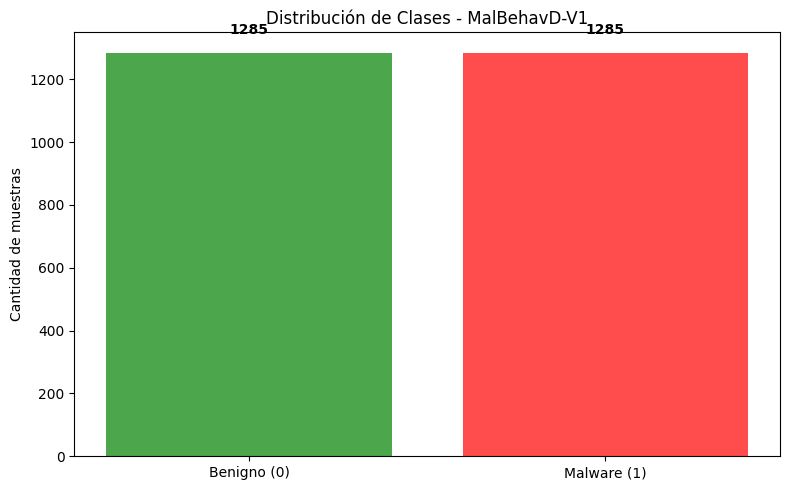

In [8]:
# Distribución de labels (0=benigno, 1=malware)
label_counts = df_clean['labels'].value_counts()
print("Distribución de clases:")
print(label_counts)
print(f"\nRatio malware/benigno: {label_counts.get(1, 0) / label_counts.get(0, 1):.2f}")

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Benigno (0)', 'Malware (1)'], [label_counts.get(0, 0), label_counts.get(1, 0)], 
              color=['green', 'red'], alpha=0.7)
ax.set_ylabel('Cantidad de muestras')
ax.set_title('Distribución de Clases - MalBehavD-V1')
for bar, count in zip(bars, [label_counts.get(0, 0), label_counts.get(1, 0)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(count), 
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis de valores nulos en secuencias de API calls

Estadísticas de longitud de secuencias:
  Mínimo: 2
  Máximo: 175
  Media: 43.19
  Mediana: 37.0
  Percentil 95: 101.0
  Percentil 99: 126.0

Muestras sin API calls: 0


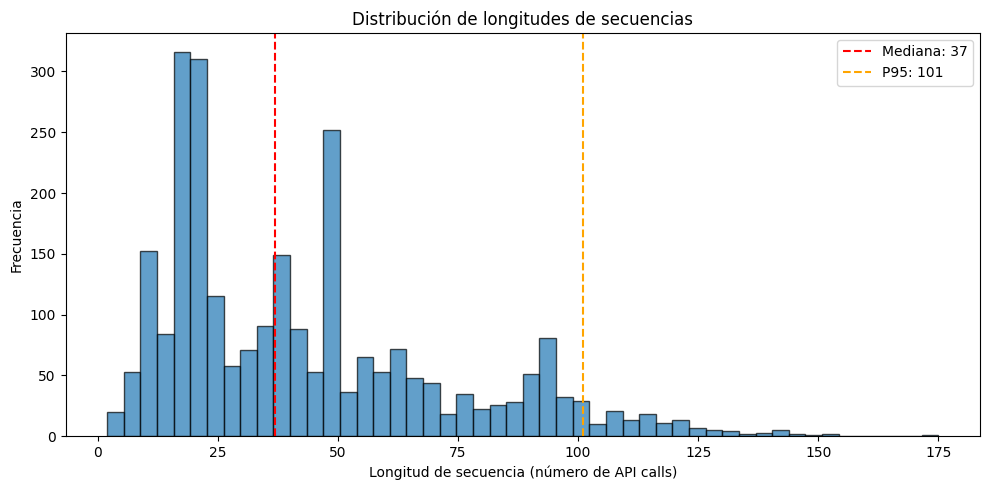

In [9]:
# Analizar longitud de secuencias (cuántos API calls por muestra)
api_cols = [col for col in df_clean.columns if col not in ['sha256', 'labels']]

# Contar API calls no nulos por fila
sequence_lengths = df_clean[api_cols].notna().sum(axis=1)

print(f"Estadísticas de longitud de secuencias:")
print(f"  Mínimo: {sequence_lengths.min()}")
print(f"  Máximo: {sequence_lengths.max()}")
print(f"  Media: {sequence_lengths.mean():.2f}")
print(f"  Mediana: {sequence_lengths.median()}")
print(f"  Percentil 95: {sequence_lengths.quantile(0.95)}")
print(f"  Percentil 99: {sequence_lengths.quantile(0.99)}")

# Muestras sin API calls (longitud 0)
zero_length = (sequence_lengths == 0).sum()
print(f"\nMuestras sin API calls: {zero_length}")

# Visualización de distribución de longitudes
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sequence_lengths, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(sequence_lengths.median(), color='red', linestyle='--', label=f'Mediana: {sequence_lengths.median():.0f}')
ax.axvline(sequence_lengths.quantile(0.95), color='orange', linestyle='--', label=f'P95: {sequence_lengths.quantile(0.95):.0f}')
ax.set_xlabel('Longitud de secuencia (número de API calls)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitudes de secuencias')
ax.legend()
plt.tight_layout()
plt.show()

### Fase 2: Crear vocabulario de API calls y codificación

In [10]:
import numpy as np
from collections import Counter

# Extraer todos los API calls únicos del dataset
all_api_calls = []
for col in api_cols:
    api_values = df_clean[col].dropna().unique()
    all_api_calls.extend(api_values)

# Contar frecuencia de cada API call
api_counter = Counter(all_api_calls)
print(f"API calls únicos totales: {len(api_counter)}")

# Mostrar los 20 API calls más frecuentes
print("\nTop 20 API calls más frecuentes:")
for api, count in api_counter.most_common(20):
    print(f"  {api}: {count}")

# API calls raros (aparecen menos de 5 veces)
rare_apis = [api for api, count in api_counter.items() if count < 5]
print(f"\nAPI calls raros (<5 ocurrencias): {len(rare_apis)}")

API calls únicos totales: 291

Top 20 API calls más frecuentes:
  NtOpenKeyEx: 120
  GetFileAttributesExW: 112
  GetTempPathW: 112
  GetFileType: 109
  NtOpenKey: 109
  NtQueryDirectoryFile: 107
  NtCreateMutant: 106
  FindResourceW: 105
  GetFileVersionInfoW: 105
  SetUnhandledExceptionFilter: 103
  NtUnmapViewOfSection: 103
  NtTerminateProcess: 102
  NtOpenFile: 102
  NtQueryAttributesFile: 102
  CreateProcessInternalW: 101
  NtDelayExecution: 101
  NtQueryKey: 100
  OleInitialize: 100
  SizeofResource: 99
  IsDebuggerPresent: 98

API calls raros (<5 ocurrencias): 36


In [11]:
# Crear vocabulario con tokens especiales
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# Construir vocabulario (excluir API calls muy raros)
vocab_apis = [api for api, count in api_counter.items() if count >= 5]
vocab = [PAD_TOKEN, UNK_TOKEN] + sorted(vocab_apis)

# Crear mapeos
api_to_idx = {api: idx for idx, api in enumerate(vocab)}
idx_to_api = {idx: api for api, idx in api_to_idx.items()}

print(f"Tamaño del vocabulario: {len(vocab)}")
print(f"  - Tokens especiales: 2 ({PAD_TOKEN}, {UNK_TOKEN})")
print(f"  - API calls: {len(vocab) - 2}")
print(f"\nPrimeros 10 elementos del vocabulario:")
for i, api in enumerate(vocab[:10]):
    print(f"  {i}: {api}")

Tamaño del vocabulario: 257
  - Tokens especiales: 2 (<PAD>, <UNK>)
  - API calls: 255

Primeros 10 elementos del vocabulario:
  0: <PAD>
  1: <UNK>
  2: CertControlStore
  3: CertOpenStore
  4: CoCreateInstance
  5: CoCreateInstanceEx
  6: CoGetClassObject
  7: CoInitializeEx
  8: CoInitializeSecurity
  9: CoUninitialize


### Fase 3: Codificar secuencias y normalizar longitud

In [12]:
# Definir longitud máxima basada en percentil 95
MAX_SEQ_LENGTH = int(sequence_lengths.quantile(0.95))
print(f"Longitud máxima de secuencia: {MAX_SEQ_LENGTH}")

def encode_sequence(row, api_cols, api_to_idx, max_length):
    """Codifica una secuencia de API calls a índices."""
    sequence = []
    for col in api_cols:
        api = row[col]
        if pd.isna(api):
            break  # Fin de la secuencia
        # Usar UNK_TOKEN para APIs no en vocabulario
        idx = api_to_idx.get(api, api_to_idx[UNK_TOKEN])
        sequence.append(idx)
    
    # Truncar si es muy larga
    if len(sequence) > max_length:
        sequence = sequence[:max_length]
    
    # Padding al final
    padding_length = max_length - len(sequence)
    sequence.extend([api_to_idx[PAD_TOKEN]] * padding_length)
    
    return sequence

# Codificar todas las secuencias
print("Codificando secuencias...")
encoded_sequences = []
for idx, row in df_clean.iterrows():
    encoded = encode_sequence(row, api_cols, api_to_idx, MAX_SEQ_LENGTH)
    encoded_sequences.append(encoded)

X = np.array(encoded_sequences)
y = df_clean['labels'].values

print(f"\nForma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"\nEjemplo de secuencia codificada (primeros 20 tokens):")
print(f"  {X[0][:20]}")

Longitud máxima de secuencia: 101
Codificando secuencias...

Forma de X: (2570, 101)
Forma de y: (2570,)

Ejemplo de secuencia codificada (primeros 20 tokens):
  [112   9 154 135  69  72 108  76 126  63 146  55 198 140 205  58 194 213
 161 125]


### Fase 4: División train/validation/test y guardado

In [13]:
from sklearn.model_selection import train_test_split
import json

# División estratificada: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 ≈ 15/85
)

print("División del dataset:")
print(f"  Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada split
print("\nDistribución de clases por split:")
for name, y_split in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    benign = (y_split == 0).sum()
    malware = (y_split == 1).sum()
    print(f"  {name}: Benigno={benign}, Malware={malware}, Ratio={malware/benign:.2f}")

División del dataset:
  Train: 1799 muestras (70.0%)
  Validation: 385 muestras (15.0%)
  Test: 386 muestras (15.0%)

Distribución de clases por split:
  Train: Benigno=899, Malware=900, Ratio=1.00
  Validation: Benigno=193, Malware=192, Ratio=0.99
  Test: Benigno=193, Malware=193, Ratio=1.00


In [14]:
# Guardar datos procesados
output_dir = f"{current_directory}/processed_data"
os.makedirs(output_dir, exist_ok=True)

# Guardar arrays numpy
np.save(f"{output_dir}/X_train.npy", X_train)
np.save(f"{output_dir}/X_val.npy", X_val)
np.save(f"{output_dir}/X_test.npy", X_test)
np.save(f"{output_dir}/y_train.npy", y_train)
np.save(f"{output_dir}/y_val.npy", y_val)
np.save(f"{output_dir}/y_test.npy", y_test)

# Guardar vocabulario
vocab_data = {
    'api_to_idx': api_to_idx,
    'idx_to_api': {str(k): v for k, v in idx_to_api.items()},  # JSON requiere keys string
    'vocab_size': len(vocab),
    'max_seq_length': MAX_SEQ_LENGTH,
    'pad_idx': api_to_idx[PAD_TOKEN],
    'unk_idx': api_to_idx[UNK_TOKEN]
}

with open(f"{output_dir}/vocabulary.json", 'w') as f:
    json.dump(vocab_data, f, indent=2)

print(f"Datos guardados en: {output_dir}")
print(f"\nArchivos creados:")
for f_name in os.listdir(output_dir):
    file_path = os.path.join(output_dir, f_name)
    size = os.path.getsize(file_path)
    print(f"  {f_name}: {size/1024:.1f} KB")

Datos guardados en: c:\Users\javil\OneDrive\Documentos\U\Data Science\Lab2-SecurityDataScience/processed_data

Archivos creados:
  gemini_embeddings.npy: 61680.1 KB
  gemini_labels.npy: 20.2 KB
  vocabulary.json: 15.2 KB
  X_test.npy: 304.7 KB
  X_train.npy: 1419.6 KB
  X_val.npy: 303.9 KB
  y_test.npy: 3.1 KB
  y_train.npy: 14.2 KB
  y_val.npy: 3.1 KB


### Resumen del preprocesamiento
El dataset ha sido limpiado y preparado para modelos de Deep Learning/NLP:
- **Columnas vacías eliminadas**: Se removieron las columnas sin datos
- **Vocabulario creado**: Mapeo de API calls a índices enteros
- **Secuencias codificadas**: Cada muestra es un array de índices de longitud fija
- **Datos divididos**: Train/Validation/Test con stratificación por clase

## 3.1 Modelo 1: TF-IDF + Random Forest
Implementación de un clasificador Random Forest usando representación TF-IDF de las secuencias de API calls.

**Enfoque NLP:** Cada muestra se trata como un "documento" donde los API calls son "palabras".

### Fase 1: Preparar datos para TF-IDF

In [15]:
# Convertir secuencias de API calls a strings (cada muestra es un "documento")
def sequence_to_string(row, api_cols):
    """Concatena los API calls de una fila en un string separado por espacios."""
    apis = []
    for col in api_cols:
        api = row[col]
        if pd.isna(api):
            break
        apis.append(str(api))
    return ' '.join(apis)

# Crear corpus de documentos
print("Convirtiendo secuencias a strings...")
documents = df_clean.apply(lambda row: sequence_to_string(row, api_cols), axis=1)
labels = df_clean['labels'].values

print(f"Total de documentos: {len(documents)}")
print(f"\nEjemplo de documento (primeros 200 caracteres):")
print(f"  '{documents.iloc[0][:200]}...'")

Convirtiendo secuencias a strings...
Total de documentos: 2570

Ejemplo de documento (primeros 200 caracteres):
  'LdrUnloadDll CoUninitialize NtQueryKey NtDuplicateObject GetShortPathNameW GetSystemInfo IsDebuggerPresent GetSystemWindowsDirectoryW NtClose GetFileVersionInfoSizeW NtOpenProcess GetFileAttributesW R...'


In [16]:
# División train/test estratificada (70/15/15)
from sklearn.model_selection import train_test_split

# Primera división: separar test
docs_temp, docs_test, y_temp_tfidf, y_test_tfidf = train_test_split(
    documents, labels, test_size=0.15, random_state=42, stratify=labels
)

# Segunda división: separar validation de train
docs_train, docs_val, y_train_tfidf, y_val_tfidf = train_test_split(
    docs_temp, y_temp_tfidf, test_size=0.176, random_state=42, stratify=y_temp_tfidf
)

print("División del dataset para TF-IDF:")
print(f"  Train: {len(docs_train)} ({len(docs_train)/len(documents)*100:.1f}%)")
print(f"  Validation: {len(docs_val)} ({len(docs_val)/len(documents)*100:.1f}%)")
print(f"  Test: {len(docs_test)} ({len(docs_test)/len(documents)*100:.1f}%)")

División del dataset para TF-IDF:
  Train: 1799 (70.0%)
  Validation: 385 (15.0%)
  Test: 386 (15.0%)


### Fase 2: Aplicar TF-IDF Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear y entrenar el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=1000,      # Limitar a 1000 features más importantes
    ngram_range=(1, 1),     # Solo unigramas (cada API call individual)
    min_df=5,               # Ignorar términos que aparecen en menos de 5 documentos
    max_df=0.95,            # Ignorar términos que aparecen en más del 95% de documentos
    sublinear_tf=True       # Aplicar escala logarítmica a TF
)

# Fit solo en train (evitar data leakage)
print("Aplicando TF-IDF...")
X_train_tfidf = tfidf_vectorizer.fit_transform(docs_train)
X_val_tfidf = tfidf_vectorizer.transform(docs_val)
X_test_tfidf = tfidf_vectorizer.transform(docs_test)

print(f"\nForma de matrices TF-IDF:")
print(f"  X_train_tfidf: {X_train_tfidf.shape}")
print(f"  X_val_tfidf: {X_val_tfidf.shape}")
print(f"  X_test_tfidf: {X_test_tfidf.shape}")

# Mostrar vocabulario
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nVocabulario TF-IDF: {len(feature_names)} términos")
print(f"Primeros 20 términos: {list(feature_names[:20])}")

Aplicando TF-IDF...

Forma de matrices TF-IDF:
  X_train_tfidf: (1799, 254)
  X_val_tfidf: (385, 254)
  X_test_tfidf: (386, 254)

Vocabulario TF-IDF: 254 términos
Primeros 20 términos: ['__exception__', 'bind', 'certcontrolstore', 'certopenstore', 'closesocket', 'cocreateinstance', 'cocreateinstanceex', 'cogetclassobject', 'coinitializeex', 'coinitializesecurity', 'connect', 'copyfilea', 'copyfilew', 'couninitialize', 'createactctxw', 'createdirectoryw', 'createjobobjectw', 'createprocessinternalw', 'createremotethread', 'createservicea']


### Fase 3: Entrenar Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier
import time

# Crear y entrenar el modelo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,           # Número de árboles
    max_depth=None,             # Sin límite de profundidad
    min_samples_split=2,        # Mínimo de muestras para dividir un nodo
    min_samples_leaf=1,         # Mínimo de muestras en una hoja
    class_weight='balanced',    # Ajustar pesos por desbalance de clases
    random_state=42,
    n_jobs=-1                   # Usar todos los cores
)

print("Entrenando Random Forest...")
start_time = time.time()
rf_model.fit(X_train_tfidf, y_train_tfidf)
training_time = time.time() - start_time

print(f"Entrenamiento completado en {training_time:.2f} segundos")
print(f"\nParámetros del modelo:")
print(f"  Número de árboles: {rf_model.n_estimators}")
print(f"  Número de features: {rf_model.n_features_in_}")
print(f"  Clases: {rf_model.classes_}")

Entrenando Random Forest...
Entrenamiento completado en 0.18 segundos

Parámetros del modelo:
  Número de árboles: 100
  Número de features: 254
  Clases: [0 1]


### Fase 4: Evaluación del Modelo
Métricas: Accuracy, Precision, Recall, F1-Score

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Predicciones en test set
y_pred = rf_model.predict(X_test_tfidf)
y_pred_proba = rf_model.predict_proba(X_test_tfidf)[:, 1]  # Probabilidad de clase 1 (malware)

# Calcular métricas
accuracy = accuracy_score(y_test_tfidf, y_pred)
precision = precision_score(y_test_tfidf, y_pred)
recall = recall_score(y_test_tfidf, y_pred)
f1 = f1_score(y_test_tfidf, y_pred)

print("=" * 50)
print("MÉTRICAS DE EVALUACIÓN - Random Forest + TF-IDF")
print("=" * 50)
print(f"\n📊 Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"🔍 Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"⚖️  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

print("\n" + "=" * 50)
print("REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 50)
print(classification_report(y_test_tfidf, y_pred, target_names=['Benigno', 'Malware']))

MÉTRICAS DE EVALUACIÓN - Random Forest + TF-IDF

📊 Accuracy:  0.9534 (95.34%)
🎯 Precision: 0.9834 (98.34%)
🔍 Recall:    0.9223 (92.23%)
⚖️  F1-Score:  0.9519 (95.19%)

REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

     Benigno       0.93      0.98      0.95       193
     Malware       0.98      0.92      0.95       193

    accuracy                           0.95       386
   macro avg       0.96      0.95      0.95       386
weighted avg       0.96      0.95      0.95       386



### ROC Curve y AUC Score

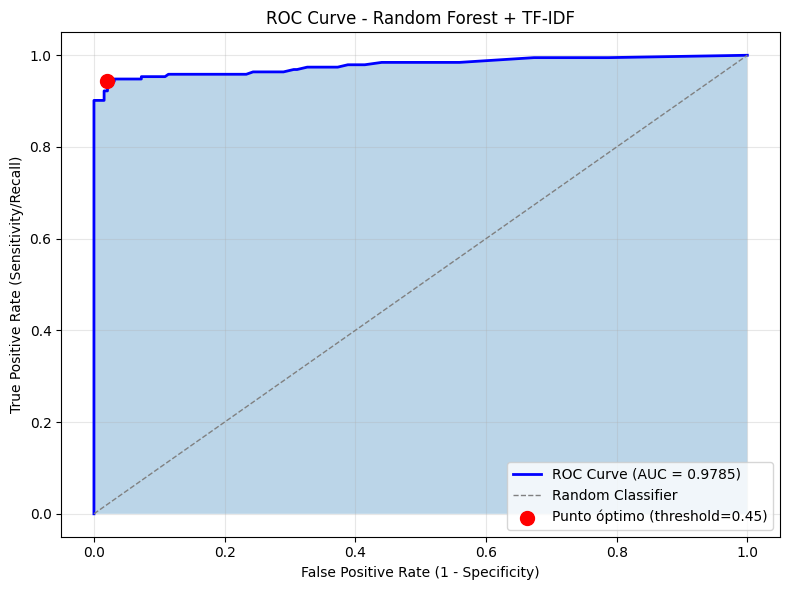


🎯 AUC Score: 0.9785
📌 Umbral óptimo (Youden): 0.4500


In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcular ROC curve y AUC
fpr, tpr, thresholds = roc_curve(y_test_tfidf, y_pred_proba)
auc_score = roc_auc_score(y_test_tfidf, y_pred_proba)

# Graficar ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.3)

ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity/Recall)')
ax.set_title('ROC Curve - Random Forest + TF-IDF')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Añadir punto óptimo (umbral de Youden)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
           label=f'Punto óptimo (threshold={optimal_threshold:.2f})', zorder=5)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"\n🎯 AUC Score: {auc_score:.4f}")
print(f"📌 Umbral óptimo (Youden): {optimal_threshold:.4f}")

### Matriz de Confusión

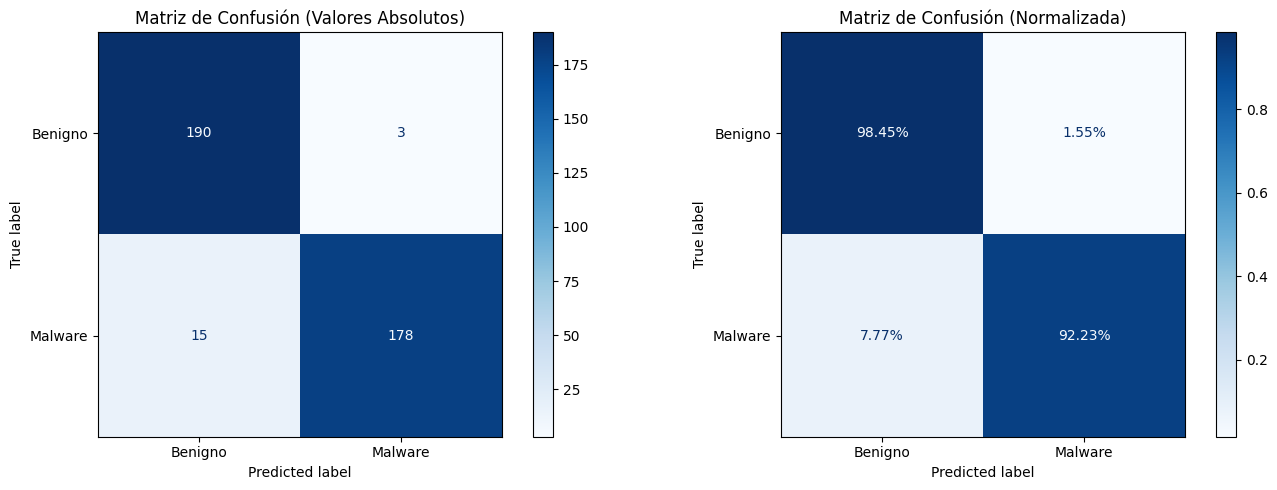


📊 Desglose de predicciones:
  ✅ True Negatives (Benigno correcto):  190
  ❌ False Positives (Benigno → Malware): 3
  ❌ False Negatives (Malware → Benigno): 15
  ✅ True Positives (Malware correcto):  178


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcular matriz de confusión
cm = confusion_matrix(y_test_tfidf, y_pred)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz con valores absolutos
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Malware'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión (Valores Absolutos)')

# Matriz normalizada (porcentajes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Benigno', 'Malware'])
disp2.plot(ax=axes[1], cmap='Blues', values_format='.2%')
axes[1].set_title('Matriz de Confusión (Normalizada)')

plt.tight_layout()
plt.show()

# Interpretación
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Desglose de predicciones:")
print(f"  ✅ True Negatives (Benigno correcto):  {tn}")
print(f"  ❌ False Positives (Benigno → Malware): {fp}")
print(f"  ❌ False Negatives (Malware → Benigno): {fn}")
print(f"  ✅ True Positives (Malware correcto):  {tp}")

### Feature Importance: API Calls más relevantes para la clasificación

TOP 20 API CALLS MÁS IMPORTANTES PARA CLASIFICACIÓN
                   api_call  importance
     createprocessinternalw    0.073561
                ntwritefile    0.061625
             regsetvalueexa    0.052596
            regcreatekeyexa    0.040396
    getsystemtimeasfiletime    0.036597
                getfilesize    0.034560
                  copyfilea    0.030411
setunhandledexceptionfilter    0.029708
     ntprotectvirtualmemory    0.029321
                drawtextexw    0.022841
             coinitializeex    0.021367
                 ntreadfile    0.020934
            ldrgetdllhandle    0.020586
               ntcreatefile    0.015580
        getsystemdirectorya    0.012576
           ntdelayexecution    0.011857
           findfirstfileexw    0.011855
          isdebuggerpresent    0.010925
              createactctxw    0.010587
           regqueryvalueexw    0.010119



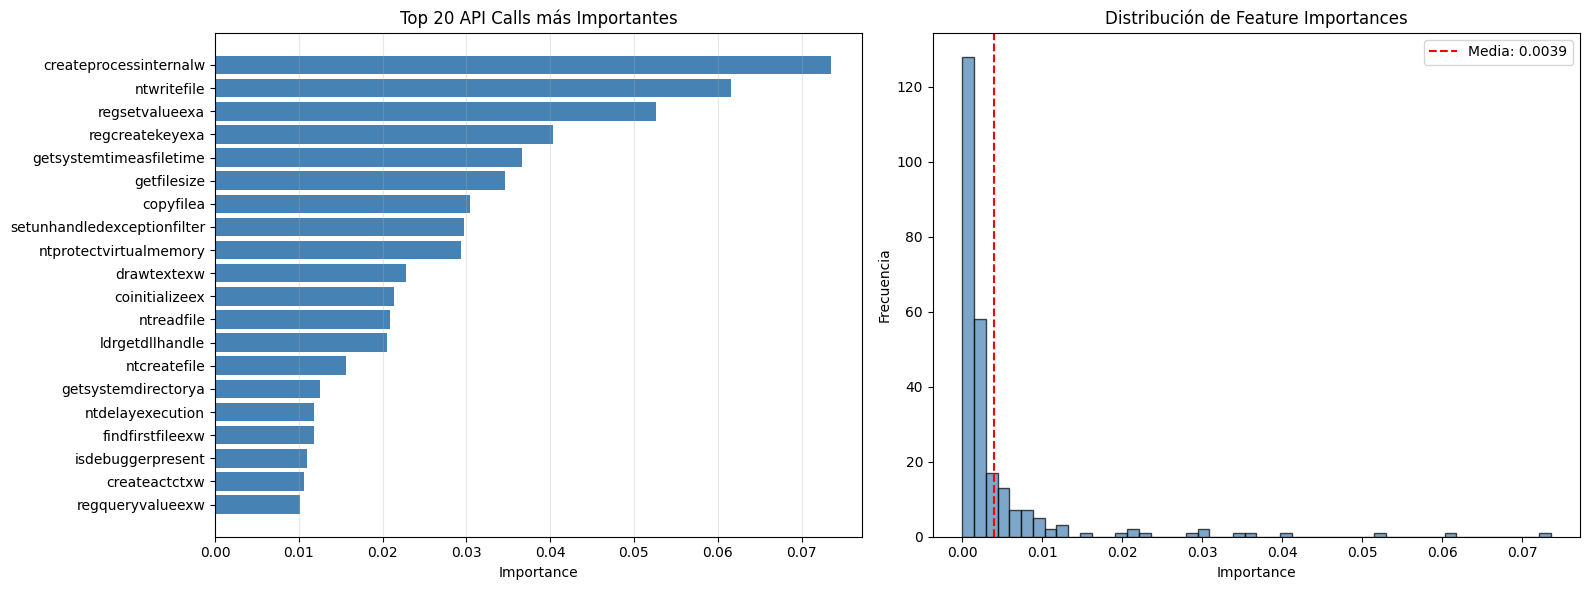


Estadísticas de Feature Importance:
  - Total features (API calls únicos): 254
  - Mean importance: 0.003937
  - Max importance: 0.073561
  - Features con importance > 0: 254
  - Top 5 API calls representan: 26.48% de la importancia total


In [22]:
# Obtener feature importance del Random Forest
feature_names = tfidf_vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

# Crear DataFrame para mejor visualización
importance_df = pd.DataFrame({
    'api_call': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Mostrar top 20 API calls más importantes
print("=" * 60)
print("TOP 20 API CALLS MÁS IMPORTANTES PARA CLASIFICACIÓN")
print("=" * 60)
print(importance_df.head(20).to_string(index=False))
print()

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 más importantes
top_20 = importance_df.head(20)
axes[0].barh(range(len(top_20)), top_20['importance'].values, color='steelblue')
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['api_call'].values)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 API Calls más Importantes')
axes[0].grid(axis='x', alpha=0.3)

# Distribución de importances (histogram)
axes[1].hist(importances, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Feature Importances')
axes[1].axvline(importances.mean(), color='red', linestyle='--', label=f'Media: {importances.mean():.4f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print(f"\nEstadísticas de Feature Importance:")
print(f"  - Total features (API calls únicos): {len(feature_names)}")
print(f"  - Mean importance: {importances.mean():.6f}")
print(f"  - Max importance: {importances.max():.6f}")
print(f"  - Features con importance > 0: {(importances > 0).sum()}")
print(f"  - Top 5 API calls representan: {top_20.head(5)['importance'].sum() / importances.sum() * 100:.2f}% de la importancia total")

---
## Resumen del Modelo TF-IDF + Random Forest

Este modelo baseline utiliza:
1. **TF-IDF (Term Frequency - Inverse Document Frequency):** Transforma las secuencias de API calls en vectores numéricos que capturan la importancia relativa de cada API call
2. **Random Forest:** Ensemble de 100 árboles de decisión que clasifica muestras como benignas o malware

### Interpretación:
- Los **API calls con mayor importance** son los más discriminativos para distinguir malware de software benigno
- APIs relacionadas con manipulación de archivos, registro, y red suelen ser indicativas de comportamiento malicioso
- Este modelo sirve como baseline para comparar con modelos más complejos (CNN, LSTM, Transformers)

---
## 3.2 Modelo 2: Gemini Embeddings + Red Neuronal

Segundo modelo de clasificación utilizando **embeddings semánticos** generados por la API de Gemini.

**Enfoque:** Cada secuencia completa de API calls se convierte en un vector denso (embedding) que captura relaciones semánticas, luego una red neuronal clasifica malware vs benigno.

### Fase 1: Configuración de la API de Gemini

In [ ]:
# ============================================
# CELDA COMENTADA - No instalar google-generativeai
# Causa conflictos con TensorFlow (protobuf)
# Los embeddings ya están generados
# ============================================

# !pip install google-generativeai tensorflow

print("⏭️ Celda saltada - No se necesitan bibliotecas de Google")

In [ ]:
# ============================================
# CELDA COMENTADA - Embeddings ya generados
# No ejecutar: causa conflictos con TensorFlow
# ============================================

# from dotenv import load_dotenv
# import google.generativeai as genai
# import time

# # ============================================
# # IMPORTANTE: Reemplaza con tu API Key de Gemini
# # ============================================
# load_dotenv()  # Cargar variables de entorno desde .env
# # Configurar la API
# GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# genai.configure(api_key=GOOGLE_API_KEY)

# print("API de Gemini configurada correctamente")

print("⏭️ Celda saltada - Los embeddings ya están generados en processed_data/")

API de Gemini configurada correctamente


c:\Users\javil\OneDrive\Documentos\U\Data Science\Lab2-SecurityDataScience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\CUDA_TEMP\ipykernel_24148\3190467287.py:2: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [ ]:
# ============================================
# CELDA COMENTADA - Embeddings ya generados
# No ejecutar: causa conflictos con TensorFlow
# ============================================

# # Verificar conexión y dimensión del embedding
# test_text = "NtClose NtOpenFile RegOpenKeyExW"
# test_result = genai.embed_content(
#     model="models/gemini-embedding-001",
#     content=test_text
# )

# test_embedding = np.array(test_result['embedding'])
# EMBEDDING_DIM = len(test_embedding)

# print(f"✓ Conexión exitosa con Gemini API")
# print(f"✓ Dimensión del embedding: {test_embedding.shape}")
# print(f"✓ EMBEDDING_DIM = {EMBEDDING_DIM}")

print("⏭️ Celda saltada - Los embeddings ya están generados en processed_data/")

✓ Conexión exitosa con Gemini API
✓ Dimensión del embedding: (3072,)
✓ EMBEDDING_DIM = 3072


### Fase 2: Generación de Embeddings
Cada muestra (secuencia completa de API calls) se convierte en un único vector de embedding.

In [ ]:
# ============================================
# CELDA COMENTADA - Embeddings ya generados
# No ejecutar: causa conflictos con TensorFlow
# ============================================

# # Reutilizar los documentos (strings de API calls) creados para TF-IDF
# # La variable 'documents' ya contiene las secuencias de API calls como strings

# embeddings_cache_path = f"{current_directory}/processed_data/gemini_embeddings.npy"
# labels_cache_path = f"{current_directory}/processed_data/gemini_labels.npy"
# partial_cache_path = f"{current_directory}/processed_data/gemini_embeddings_partial.npy"

# def generate_embeddings_with_rate_limit(texts, requests_per_minute=90, model_name="models/gemini-embedding-001"):
#     """
#     Genera embeddings respetando el rate limit de Gemini (100 requests/minuto free tier).
#     """
#     # ... función completa comentada ...
#     pass

# print("Función de generación de embeddings definida ✓")

print("⏭️ Celda saltada - Los embeddings ya están generados en processed_data/")

Función de generación de embeddings definida ✓
Nota: Con el free tier de Gemini (~100 req/min), generar 2570 embeddings tomará ~29 minutos


In [ ]:
# ============================================
# CELDA COMENTADA - Embeddings ya generados
# No ejecutar: causa conflictos con TensorFlow
# ============================================

# # Generar embeddings o cargar desde cache
# if os.path.exists(embeddings_cache_path) and os.path.exists(labels_cache_path):
#     print("Cargando embeddings desde cache...")
#     embeddings_matrix = np.load(embeddings_cache_path)
#     labels_gemini = np.load(labels_cache_path)
#     print(f"✓ Embeddings cargados: {embeddings_matrix.shape}")
# else:
#     print("Cache no encontrado. Generando embeddings...")
#     # ... código de generación comentado ...

# print(f"\nResumen:")
# print(f"  - Shape de embeddings: {embeddings_matrix.shape}")
# print(f"  - Shape de labels: {labels_gemini.shape}")
# print(f"  - Dimensión de cada embedding: {embeddings_matrix.shape[1]}")

print("⏭️ Celda saltada - Los embeddings se cargan en la Fase 3")

Cargando embeddings desde cache...
✓ Embeddings cargados: (2570, 3072)

Resumen:
  - Shape de embeddings: (2570, 3072)
  - Shape de labels: (2570,)
  - Dimensión de cada embedding: 3072


### Fase 3: Preparación del Dataset
División 70% train / 30% test (sin normalización inicial).

In [25]:
# ============================================
# CARGA INDEPENDIENTE DE EMBEDDINGS (sin Google APIs)
# ============================================
import os
import numpy as np
from sklearn.model_selection import train_test_split

# Definir rutas
current_directory = os.getcwd()
embeddings_cache_path = f"{current_directory}/processed_data/gemini_embeddings.npy"
labels_cache_path = f"{current_directory}/processed_data/gemini_labels.npy"

# Cargar embeddings desde cache
print("Cargando embeddings desde cache...")
embeddings_matrix = np.load(embeddings_cache_path)
labels_gemini = np.load(labels_cache_path)
print(f"✓ Embeddings cargados: {embeddings_matrix.shape}")
print(f"✓ Labels cargados: {labels_gemini.shape}")

# División 70% train / 30% test estratificada
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    embeddings_matrix, 
    labels_gemini, 
    test_size=0.30, 
    random_state=42, 
    stratify=labels_gemini
)

print("\nDivisión del dataset para embeddings:")
print(f"  Train: {X_train_emb.shape[0]} muestras ({X_train_emb.shape[0]/len(embeddings_matrix)*100:.1f}%)")
print(f"  Test: {X_test_emb.shape[0]} muestras ({X_test_emb.shape[0]/len(embeddings_matrix)*100:.1f}%)")

print(f"\nFormas de los arrays:")
print(f"  X_train_emb: {X_train_emb.shape}")
print(f"  X_test_emb: {X_test_emb.shape}")
print(f"  y_train_emb: {y_train_emb.shape}")
print(f"  y_test_emb: {y_test_emb.shape}")

# Verificar distribución de clases
print("\nDistribución de clases:")
for name, y_split in [('Train', y_train_emb), ('Test', y_test_emb)]:
    benign = (y_split == 0).sum()
    malware = (y_split == 1).sum()
    print(f"  {name}: Benigno={benign}, Malware={malware}, Ratio={malware/benign:.2f}")

Cargando embeddings desde cache...
✓ Embeddings cargados: (2570, 3072)
✓ Labels cargados: (2570,)

División del dataset para embeddings:
  Train: 1799 muestras (70.0%)
  Test: 771 muestras (30.0%)

Formas de los arrays:
  X_train_emb: (1799, 3072)
  X_test_emb: (771, 3072)
  y_train_emb: (1799,)
  y_test_emb: (771,)

Distribución de clases:
  Train: Benigno=899, Malware=900, Ratio=1.00
  Test: Benigno=386, Malware=385, Ratio=1.00


### Fase 4: Construcción de la Red Neuronal
Arquitectura simple para evitar overfitting:
- Input → Dense(128, relu) → Dropout(0.3) → Dense(64, relu) → Dense(1, sigmoid)


IMPORTANNTE: se debe desactivar el primern entorno virtual y crear uno nuevo cono tensor flow para esta parte

In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Definir la arquitectura del modelo
input_dim = X_train_emb.shape[1]  # Dimensión del embedding

nn_model = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
print("Arquitectura del modelo:")
print("=" * 50)
nn_model.summary()

Arquitectura del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,665 (1.53 MB)

 Trainable params: 401,665 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

### Fase 5: Entrenamiento del Modelo
Utilizamos `validation_split=0.2` para EarlyStopping y `class_weight` para manejar el desbalance.

In [27]:
# Calcular class weights para manejar desbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_emb),
    y=y_train_emb
)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}
print(f"Class weights: {class_weights}")

# Definir callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Entrenar el modelo
print("\nIniciando entrenamiento...")
print("=" * 50)

history = nn_model.fit(
    X_train_emb,
    y_train_emb,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Entrenamiento completado")

Class weights: {0: np.float64(1.0005561735261401), 1: np.float64(0.9994444444444445)}

Iniciando entrenamiento...
Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7797 - loss: 0.5311 - val_accuracy: 0.8722 - val_loss: 0.3258 - learning_rate: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9034 - loss: 0.2672 - val_accuracy: 0.9222 - val_loss: 0.2110 - learning_rate: 0.0010
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9229 - loss: 0.2152 - val_accuracy: 0.9361 - val_loss: 0.1871 - learning_rate: 0.0010
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9284 - loss: 0.2039 - val_accuracy: 0.9333 - val_loss: 0.1805 - learning_rate: 0.0010
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9361 - loss: 0.1802 - val_accuracy: 0.9417 - val_loss: 0.1755 - learning_rate: 0.0010
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9382 - loss: 0.1721 - val_accuracy: 0.9444 - val_loss: 0.1736 - learning

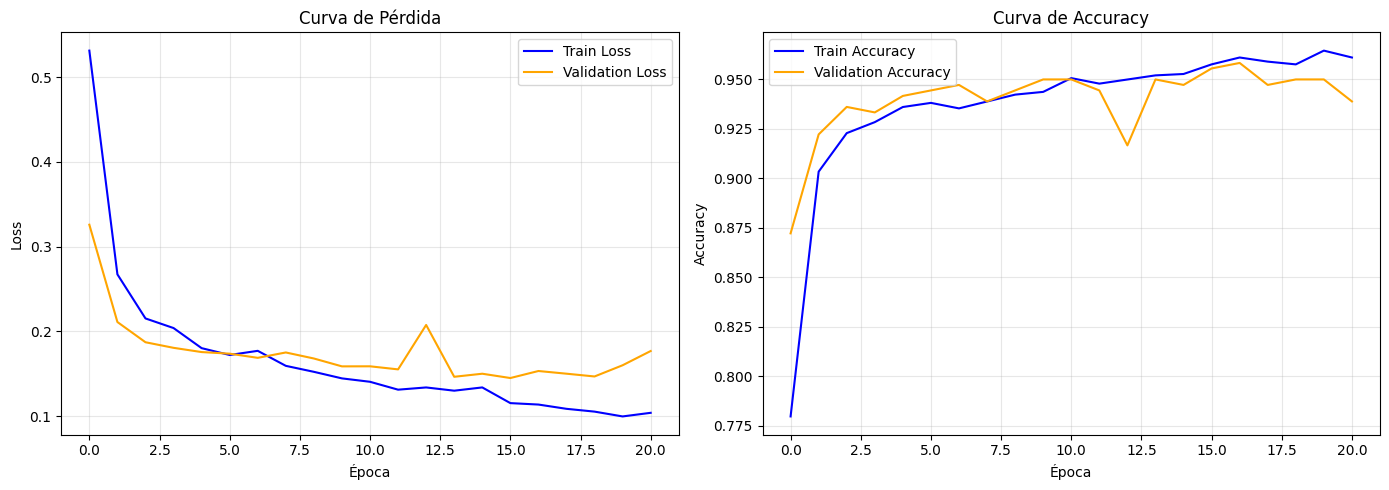


Métricas finales de entrenamiento:
  Train Loss: 0.1039
  Val Loss: 0.1768
  Train Accuracy: 0.9611
  Val Accuracy: 0.9389


In [28]:
# Visualizar curvas de aprendizaje
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Curva de Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas finales del entrenamiento
print(f"\nMétricas finales de entrenamiento:")
print(f"  Train Loss: {history.history['loss'][-1]:.4f}")
print(f"  Val Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")

### Fase 6: Evaluación del Modelo
Métricas: Accuracy, Precision, Recall, F1-Score, ROC-AUC

In [29]:
# Predicciones en test set
y_pred_proba_nn = nn_model.predict(X_test_emb).flatten()
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int)

# Calcular métricas
accuracy_nn = accuracy_score(y_test_emb, y_pred_nn)
precision_nn = precision_score(y_test_emb, y_pred_nn)
recall_nn = recall_score(y_test_emb, y_pred_nn)
f1_nn = f1_score(y_test_emb, y_pred_nn)

print("=" * 60)
print("MÉTRICAS DE EVALUACIÓN - Red Neuronal + Gemini Embeddings")
print("=" * 60)
print(f"\n📊 Accuracy:  {accuracy_nn:.4f} ({accuracy_nn*100:.2f}%)")
print(f"🎯 Precision: {precision_nn:.4f} ({precision_nn*100:.2f}%)")
print(f"🔍 Recall:    {recall_nn:.4f} ({recall_nn*100:.2f}%)")
print(f"⚖️  F1-Score:  {f1_nn:.4f} ({f1_nn*100:.2f}%)")

print("\n" + "=" * 60)
print("REPORTE DE CLASIFICACIÓN DETALLADO")
print("=" * 60)
print(classification_report(y_test_emb, y_pred_nn, target_names=['Benigno', 'Malware']))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MÉTRICAS DE EVALUACIÓN - Red Neuronal + Gemini Embeddings

📊 Accuracy:  0.9494 (94.94%)
🎯 Precision: 0.9505 (95.05%)
🔍 Recall:    0.9481 (94.81%)
⚖️  F1-Score:  0.9493 (94.93%)

REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

     Benigno       0.95      0.95      0.95       386
     Malware       0.95      0.95      0.95       385

    accuracy                           0.95       771
   macro avg       0.95      0.95      0.95       771
weighted avg       0.95      0.95      0.95       771



### ROC Curve y AUC Score

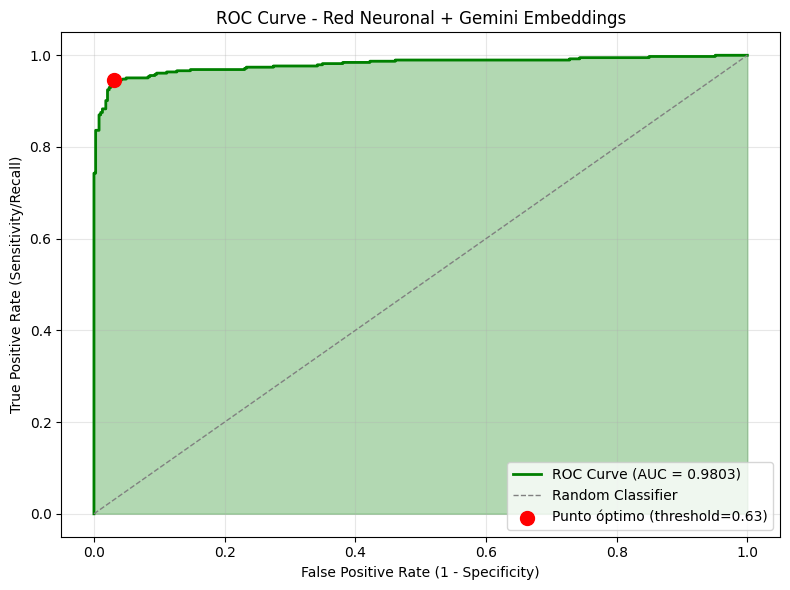


🎯 AUC Score: 0.9803
📌 Umbral óptimo (Youden): 0.6309


In [30]:
# Calcular ROC curve y AUC
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test_emb, y_pred_proba_nn)
auc_score_nn = roc_auc_score(y_test_emb, y_pred_proba_nn)

# Graficar ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_nn, tpr_nn, color='green', lw=2, label=f'ROC Curve (AUC = {auc_score_nn:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr_nn, tpr_nn, alpha=0.3, color='green')

ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity/Recall)')
ax.set_title('ROC Curve - Red Neuronal + Gemini Embeddings')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

# Añadir punto óptimo (umbral de Youden)
optimal_idx_nn = np.argmax(tpr_nn - fpr_nn)
optimal_threshold_nn = thresholds_nn[optimal_idx_nn]
ax.scatter(fpr_nn[optimal_idx_nn], tpr_nn[optimal_idx_nn], color='red', s=100, 
           label=f'Punto óptimo (threshold={optimal_threshold_nn:.2f})', zorder=5)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

print(f"\n🎯 AUC Score: {auc_score_nn:.4f}")
print(f"📌 Umbral óptimo (Youden): {optimal_threshold_nn:.4f}")

### Matriz de Confusión

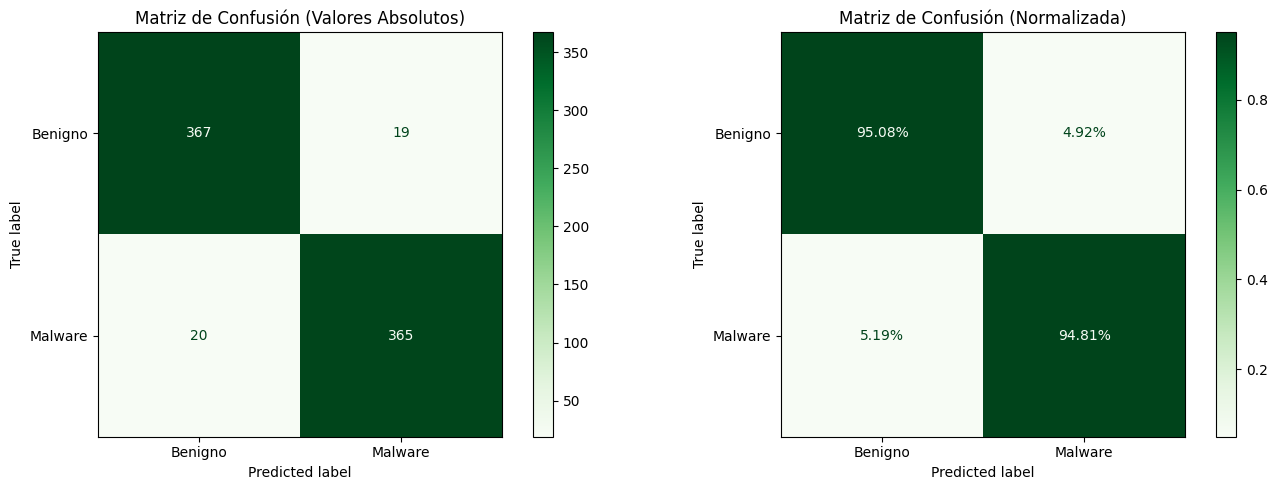


📊 Desglose de predicciones:
  ✅ True Negatives (Benigno correcto):  367
  ❌ False Positives (Benigno → Malware): 19
  ❌ False Negatives (Malware → Benigno): 20
  ✅ True Positives (Malware correcto):  365


In [31]:
# Calcular matriz de confusión
cm_nn = confusion_matrix(y_test_emb, y_pred_nn)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz con valores absolutos
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=['Benigno', 'Malware'])
disp1.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Matriz de Confusión (Valores Absolutos)')

# Matriz normalizada (porcentajes)
cm_normalized_nn = cm_nn.astype('float') / cm_nn.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_nn, display_labels=['Benigno', 'Malware'])
disp2.plot(ax=axes[1], cmap='Greens', values_format='.2%')
axes[1].set_title('Matriz de Confusión (Normalizada)')

plt.tight_layout()
plt.show()

# Interpretación
tn_nn, fp_nn, fn_nn, tp_nn = cm_nn.ravel()
print(f"\n📊 Desglose de predicciones:")
print(f"  ✅ True Negatives (Benigno correcto):  {tn_nn}")
print(f"  ❌ False Positives (Benigno → Malware): {fp_nn}")
print(f"  ❌ False Negatives (Malware → Benigno): {fn_nn}")
print(f"  ✅ True Positives (Malware correcto):  {tp_nn}")

---
## 3.3 Comparación de Modelos
Análisis comparativo entre el Modelo 1 (TF-IDF + Random Forest) y el Modelo 2 (Gemini Embeddings + Red Neuronal).

In [32]:
# Crear tabla comparativa de métricas
comparison_data = {
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Modelo 1\n(TF-IDF + RF)': [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{auc_score:.4f}"
    ],
    'Modelo 2\n(Gemini + NN)': [
        f"{accuracy_nn:.4f}",
        f"{precision_nn:.4f}",
        f"{recall_nn:.4f}",
        f"{f1_nn:.4f}",
        f"{auc_score_nn:.4f}"
    ],
    'Diferencia': [
        f"{(accuracy_nn - accuracy)*100:+.2f}%",
        f"{(precision_nn - precision)*100:+.2f}%",
        f"{(recall_nn - recall)*100:+.2f}%",
        f"{(f1_nn - f1)*100:+.2f}%",
        f"{(auc_score_nn - auc_score)*100:+.2f}%"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

COMPARACIÓN DE MODELOS
  Métrica Modelo 1\n(TF-IDF + RF) Modelo 2\n(Gemini + NN) Diferencia
 Accuracy                  0.9534                  0.9494     -0.40%
Precision                  0.9834                  0.9505     -3.29%
   Recall                  0.9223                  0.9481     +2.58%
 F1-Score                  0.9519                  0.9493     -0.26%
  AUC-ROC                  0.9785                  0.9803     +0.18%


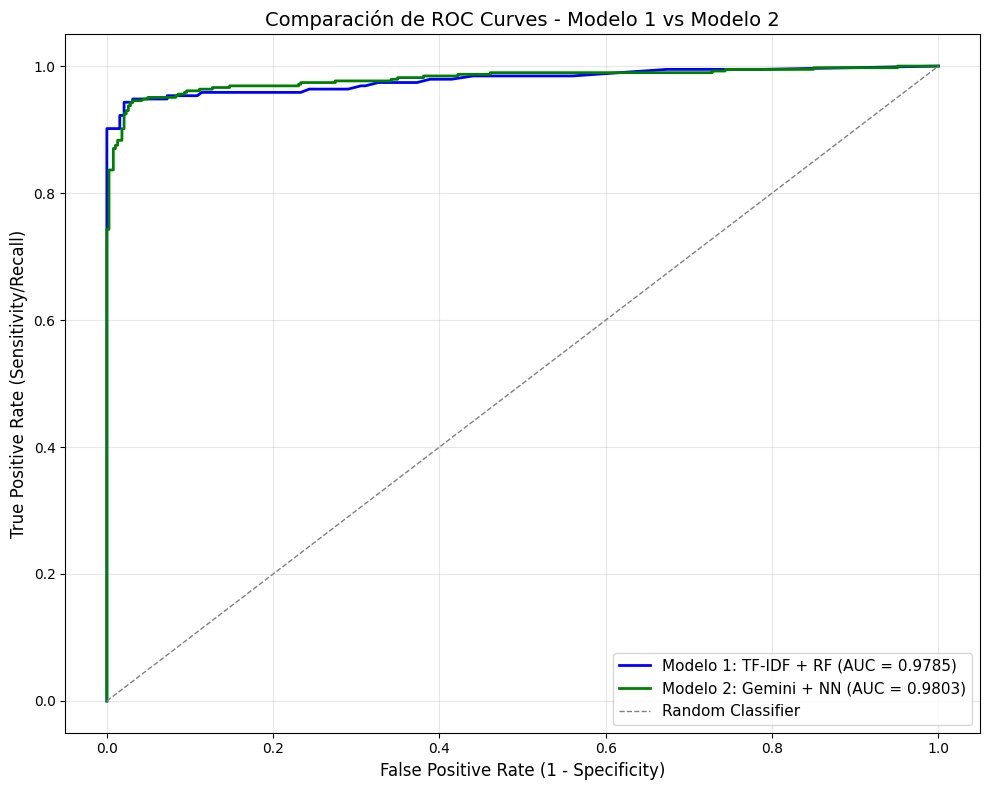


🏆 Mejor modelo según AUC-ROC: Modelo 2 (Gemini Embeddings + Red Neuronal)
   Diferencia de AUC: 0.18%


In [33]:
# Comparar ROC Curves de ambos modelos
fig, ax = plt.subplots(figsize=(10, 8))

# Modelo 1: TF-IDF + Random Forest
ax.plot(fpr, tpr, color='blue', lw=2, label=f'Modelo 1: TF-IDF + RF (AUC = {auc_score:.4f})')

# Modelo 2: Gemini + Neural Network
ax.plot(fpr_nn, tpr_nn, color='green', lw=2, label=f'Modelo 2: Gemini + NN (AUC = {auc_score_nn:.4f})')

# Clasificador aleatorio
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity/Recall)', fontsize=12)
ax.set_title('Comparación de ROC Curves - Modelo 1 vs Modelo 2', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Determinar el mejor modelo
if auc_score_nn > auc_score:
    mejor_modelo = "Modelo 2 (Gemini Embeddings + Red Neuronal)"
    diferencia_auc = auc_score_nn - auc_score
else:
    mejor_modelo = "Modelo 1 (TF-IDF + Random Forest)"
    diferencia_auc = auc_score - auc_score_nn

print(f"\n🏆 Mejor modelo según AUC-ROC: {mejor_modelo}")
print(f"   Diferencia de AUC: {diferencia_auc*100:.2f}%")

### Análisis Comparativo

#### Modelo 1: TF-IDF + Random Forest
**Ventajas:**
- Interpretable: podemos ver qué API calls son más importantes para la clasificación
- Rápido de entrenar: no requiere GPU ni APIs externas
- Robusto: Random Forest es resistente al overfitting

**Desventajas:**
- No captura relaciones semánticas entre API calls
- Pierde información del orden de las llamadas

#### Modelo 2: Gemini Embeddings + Red Neuronal  
**Ventajas:**
- Captura relaciones semánticas complejas entre API calls
- Los embeddings de Gemini están pre-entrenados en grandes corpus de texto
- Puede generalizar mejor a nuevos patrones de malware

**Desventajas:**
- Requiere API externa (dependencia, costos, latencia)
- Menos interpretable (caja negra)
- Requiere más tiempo para generar embeddings

### Conclusiones
*(Completar después de ejecutar ambos modelos y comparar resultados)*

1. **¿Cuál modelo detecta mejor el malware?** — Analizar Recall (minimizar falsos negativos es crítico en detección de malware)
2. **¿Cuál modelo tiene menor tasa de falsas alarmas?** — Analizar Precision
3. **¿Vale la pena la complejidad adicional del Modelo 2?** — Comparar mejora vs overhead